Description : Import des bibliothèques scikit-learn et chargement du dataset.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

df = pd.read_csv('data/dataset.csv')

print("=== Dataset chargé ===")
print(df.head())
print(f"\nDimensions : {df.shape}")

=== Dataset chargé ===
  client_id tranche_age                region abonnement_type  \
0      C001       70-79              Bretagne         Basique   
1      C002       60-69             Occitanie         Basique   
2      C003       70-79              Bretagne         Basique   
3      C004       70-79  Auvergne-Rhône-Alpes         Premium   
4      C005       70-79             Occitanie         Basique   

   anciennete_mois mobilite                            interets  \
0                7  Moyenne  accompagnement,santé,administratif   
1               11  Moyenne                             loisirs   
2               20  Moyenne               administratif,loisirs   
3               35   Faible                 santé,administratif   
4               39   Élevée                      accompagnement   

        categorie         prestation   prix  duree_min  niveau     mois  \
0           Santé      Suivi médical  56.07         90  Facile  2025-02   
1         Loisirs    Atelier créa

Description : Vérification des valeurs manquantes, des doublons et de la répartition de la variable cible.

In [10]:
print("=== Qualité des données ===")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"Doublons           : {df.duplicated().sum()}")

print("\nRépartition de la cible :")
print(df['categorie'].value_counts())
print(f"\nProportion :\n{df['categorie'].value_counts(normalize=True).apply(lambda x: f'{x:.2%}')}")

=== Qualité des données ===
Valeurs manquantes : 0
Doublons           : 0

Répartition de la cible :
categorie
Accompagnement    156
Santé             149
Loisirs           109
Administratif      86
Name: count, dtype: int64

Proportion :
categorie
Accompagnement    31.20%
Santé             29.80%
Loisirs           21.80%
Administratif     17.20%
Name: proportion, dtype: object


Description : Encodage des variables catégorielles avec get_dummies (comme dans le cours), sélection des features et de la cible, puis division en train (80%) et test (20%) avec stratification.


In [11]:
df_ml = pd.get_dummies(df[['tranche_age', 'region', 'abonnement_type', 'anciennete_mois', 'mobilite', 'categorie']])

X = df_ml.drop(columns=[c for c in df_ml.columns if c.startswith('categorie_')])
y = df['categorie']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("=== Séparation Train / Test ===")
print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

=== Séparation Train / Test ===
Train : 400 lignes
Test  : 100 lignes


Description : Normalisation des données avec StandardScaler : fit_transform sur le train, transform sur le test pour éviter toute fuite de données.

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Standardisation appliquée ===")
print("Moyenne = 0, Écart-type = 1")

=== Standardisation appliquée ===
Moyenne = 0, Écart-type = 1


Description : Entraînement du modèle RandomForestClassifier avec 100 arbres sur les données d'entraînement.

In [13]:
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train_scaled, y_train)

print("=== Modèle entraîné ===")
print("RandomForestClassifier — 100 arbres")

=== Modèle entraîné ===
RandomForestClassifier — 100 arbres


Description : Évaluation des performances sur le test set avec l'accuracy et la matrice de confusion.



=== Résultats ===
Accuracy : 34.00%


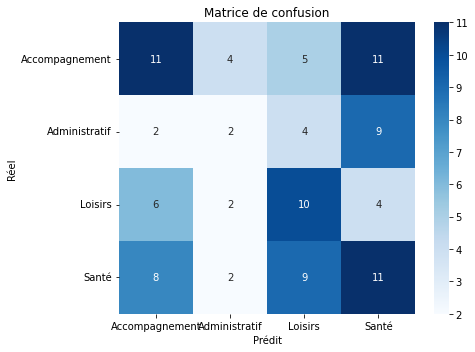

In [14]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== Résultats ===")
print(f"Accuracy : {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

Description : Test sur 3 profils clients types pour vérifier la cohérence métier des prédictions.

In [15]:
profils = pd.DataFrame({
    'tranche_age': ['80+',           '60-69',   '70-79'],
    'region':      ['Île-de-France', 'PACA',    'Bretagne'],
    'abonnement_type': ['Basique',   'Premium', 'Basique'],
    'anciennete_mois': [3,           48,        20],
    'mobilite':    ['Faible',        'Élevée',  'Moyenne']
})

profils_encoded = pd.get_dummies(profils).reindex(columns=X.columns, fill_value=0)
profils_scaled = scaler.transform(profils_encoded)
predictions = model.predict(profils_scaled)

print("=== Test profils types ===")
for i, pred in enumerate(predictions):
    print(f"\nProfil {i+1} : {profils.iloc[i]['tranche_age']} | {profils.iloc[i]['mobilite']}")
    print(f"  → Catégorie recommandée : {pred}")

=== Test profils types ===

Profil 1 : 80+ | Faible
  → Catégorie recommandée : Accompagnement

Profil 2 : 60-69 | Élevée
  → Catégorie recommandée : Administratif

Profil 3 : 70-79 | Moyenne
  → Catégorie recommandée : Accompagnement
